In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from pycontrails import Fleet

In [2]:
dff = pd.read_parquet("../data/filed/filed_trajectories_EAGWP100.parquet")
fleetf = Fleet(data=dff)
print(f"Fleet contains {fleetf.n_flights} flights")

dfo = pd.read_parquet("../data/optimised/optimised_trajectories_EAGWP100.parquet")
fleeto = Fleet(data=dfo)
print(f"Fleet contains {fleeto.n_flights} flights")

meta = pd.read_parquet("../data/filed/filed_meta.parquet")

Fleet contains 4112 flights
Fleet contains 4112 flights


In [3]:
meta.query("dep == 'BIKF'")
fid = 2025
meta.query("flight_id == @fid")

,flight_id,dep,dest,typecode,eobt,eta,day_pair,flight_time,flown_distance,fuel_use,co2eq_gwp_pulse_100_co2,co2eq_gwp_pulse_100_contrails,co2eq_gwp_pulse_100_total
2025,2025,BIKF,EHAM,A20N,2023-12-16 06:30:00,2023-12-16 09:08:00,6,0 days 02:26:44,2096.955272,5059.776592,16033.682646,25590.146677,41623.829323


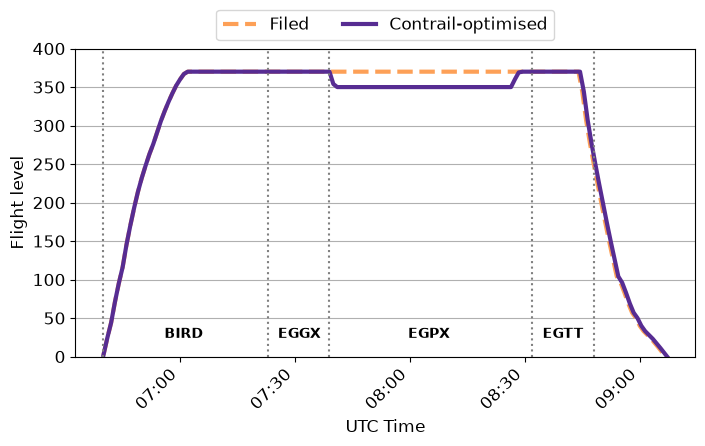

In [4]:
import matplotlib.dates as mdates
from cane.colors import colors, sns_idx


def plot_trajectory_vertical(dff, dfo, callsign=None, save_path=None):
    fig, ax = plt.subplots(figsize=(8, 4))
    plt.plot(dff.timestamp, dff.fl, linestyle="--", label="Filed", linewidth=3, color=sns.color_palette("Oranges")[2])
    plt.plot(dfo.timestamp, dfo.fl, label="Contrail-optimised", linewidth=3, color=sns.color_palette("Purples")[5])
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))  #%Y-%m-%d

    ax.set_ylim([0, 400])
    plt.xticks(rotation=45, ha="right")
    ax.set_ylabel("Flight level", fontsize=12)
    ax.set_xlabel("UTC Time", fontsize=12)
    ax.set_ylim(bottom=0)
    plt.grid(axis="y")
    ax.tick_params(labelsize=12)

    plt.legend(loc='lower center', ncol=2, bbox_to_anchor=(0.5, 1), fontsize=12)

    # Find first and last x for each category
    bounds = dff.groupby('fir')['timestamp'].agg(['first', 'last']).sort_values(by='first')
    # Add vertical lines for boundaries
    for cat, (start, end) in bounds.iterrows():
        plt.axvline(start, color='gray', linestyle='dotted')
        mid = start + (end - start) / 2
        plt.text(mid, plt.ylim()[1] * 0.05, cat if cat != "EGGX" else " EGGX", ha='center', va='bottom', fontsize=10,
                 fontweight="bold",
                 color='black',
                 rotation=0)  #, bbox=dict(boxstyle="square", ec="none", fc=colors[sns_idx["lightblue"]], alpha=0.5))
    plt.axvline(bounds['last'].iloc[-1], color='gray', linestyle='dotted')

    if callsign:
        fig.suptitle(f"Flight {callsign}", y=1.02, fontsize=14)

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    else:
        plt.show()


plot_trajectory_vertical(
    dff.query("flight_id == @fid"),
    dfo.query("flight_id == @fid"),
    # callsign="KLM1234",
    # save_path="./figures/fig02_old.png"
)

In [5]:
# dff.query("flight_id == @fid")  # FL 370
# dfo.query("flight_id == @fid")  # FL 350

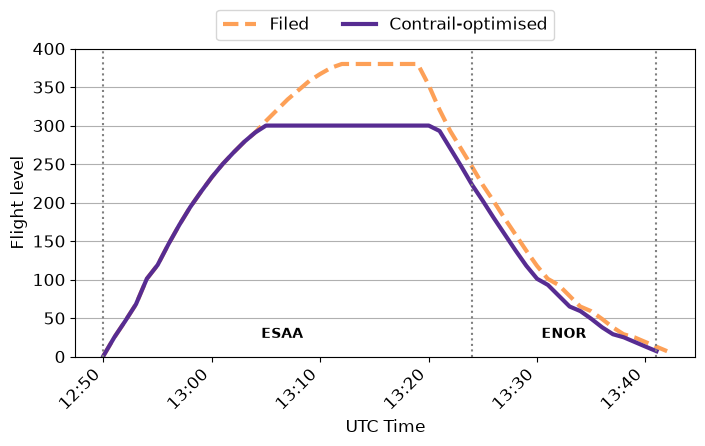

In [6]:
#fid = meta.sample().flight_id.values[0]
fid = 2554

plot_trajectory_vertical(
    dff.query("flight_id == @fid"),
    dfo.query("flight_id == @fid"),
    # callsign="KLM1234",
    # save_path="./figures/fig02_old.png"
)

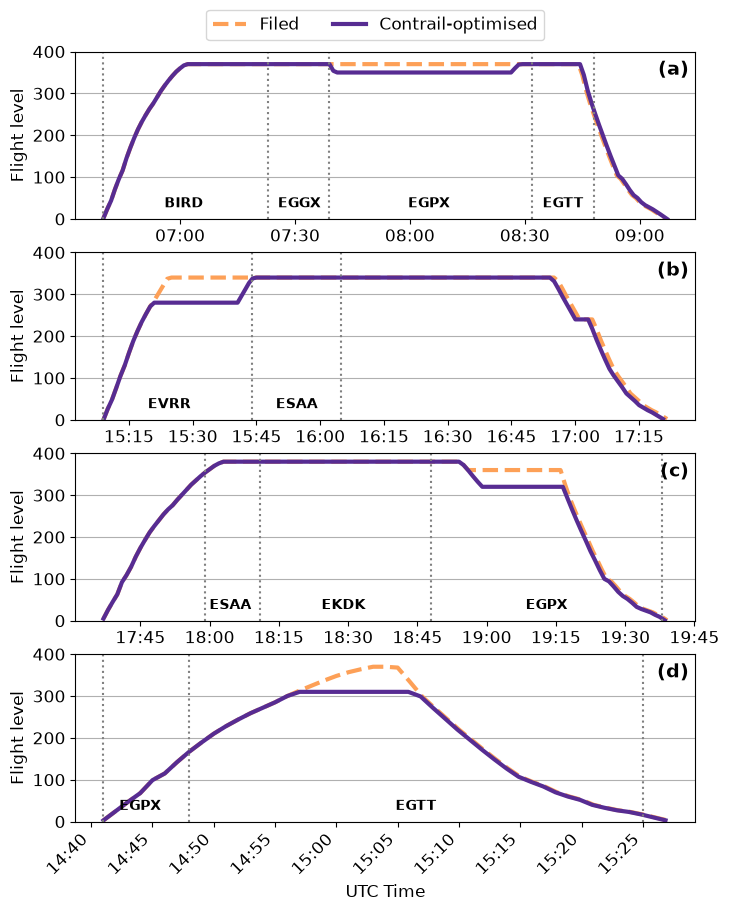

In [7]:
import matplotlib.dates as mdates
from cane.colors import colors, sns_idx


def plot_trajectory_vertical_four(dffs, dfos, callsign=None, save_path=None):
    fig, axes = plt.subplots(figsize=(8, 10), nrows=4)

    for i, (dff, dfo) in enumerate(zip(dffs, dfos)):
        axes[i].plot(dff.timestamp, dff.fl, linestyle="--", label="Filed", linewidth=3,
                     color=sns.color_palette("Oranges")[2])
        axes[i].plot(dfo.timestamp, dfo.fl, label="Contrail-optimised", linewidth=3,
                     color=sns.color_palette("Purples")[5])
        axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))  #%Y-%m-%d

        axes[i].set_ylim([0, 400])
        plt.xticks(rotation=45, ha="right")
        axes[i].set_ylabel("Flight level", fontsize=12)
        axes[i].set_ylim(bottom=0)
        axes[i].grid(axis="y")
        axes[i].tick_params(labelsize=12)

        # Find first and last x for each category
        bounds = dff.groupby('fir')['timestamp'].agg(['first', 'last']).sort_values(by='first')
        # Add vertical lines for boundaries
        for cat, (start, end) in bounds.iterrows():
            axes[i].axvline(start, color='gray', linestyle='dotted')
            mid = start + (end - start) / 2
            axes[i].text(mid, axes[i].get_ylim()[1] * 0.05, cat if cat != "EGGX" else " EGGX", ha='center', va='bottom',
                         fontsize=10,
                         fontweight="bold",
                         color='black',
                         rotation=0)  #, bbox=dict(boxstyle="square", ec="none", fc=colors[sns_idx["lightblue"]], alpha=0.5))
        axes[i].axvline(bounds['last'].iloc[-1], color='gray', linestyle='dotted')

        if callsign:
            fig.suptitle(f"Flight {callsign}", y=1.02, fontsize=14)

    axes[3].set_xlabel("UTC Time", fontsize=12)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 0.93), fontsize=12)

    axes[0].text(0.99, 0.95, "(a)",
                 transform=axes[0].transAxes,
                 fontsize=14, fontweight="bold",
                 va="top", ha="right")

    axes[1].text(0.99, 0.95, "(b)",
                 transform=axes[1].transAxes,
                 fontsize=14, fontweight="bold",
                 va="top", ha="right")

    axes[2].text(0.99, 0.95, "(c)",
                 transform=axes[2].transAxes,
                 fontsize=14, fontweight="bold",
                 va="top", ha="right")

    axes[3].text(0.99, 0.95, "(d)",
                 transform=axes[3].transAxes,
                 fontsize=14, fontweight="bold",
                 va="top", ha="right")

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    else:
        plt.show()

fids = [
    2025, 2600, 1828, 3365
]

dffs = [dff.query("flight_id == @fid") for fid in fids]
dfos = [dfo.query("flight_id == @fid") for fid in fids]

plot_trajectory_vertical_four(dffs, dfos, save_path="../figures/fig02.png")

In [8]:
print(fids)
meta.query("flight_id in @fids")

[2025, 2600, 1828, 3365]


,flight_id,dep,dest,typecode,eobt,eta,day_pair,flight_time,flown_distance,fuel_use,co2eq_gwp_pulse_100_co2,co2eq_gwp_pulse_100_contrails,co2eq_gwp_pulse_100_total
1828,1828,EPGD,EGPH,A320,2023-09-17 17:25:00,2023-09-17 19:36:00,5,0 days 02:02:05,1497.341237,4583.357142,14491.533642,93477.954732,107969.488373
2025,2025,BIKF,EHAM,A20N,2023-12-16 06:30:00,2023-12-16 09:08:00,6,0 days 02:26:44,2096.955272,5059.776592,16033.682646,25590.146677,41623.829323
2600,2600,EVRA,EBBR,BCS3,2023-12-17 14:59:00,2023-12-17 17:23:00,6,0 days 02:12:37,1513.206031,5061.183659,16030.151065,7609.444079,23639.595144
3365,3365,EGAA,EGSS,A20N,2023-12-22 14:30:00,2023-12-22 15:31:00,7,0 days 00:45:59,586.280941,1709.464820,5439.786195,10536.190779,15975.976974
